In [2]:
!pip install -q scikeras==0.13.0 "scikit-learn==1.5.0"

In [3]:
import sklearn, scikeras
print("sklearn:", sklearn.__version__)
print("scikeras:", scikeras.__version__)

sklearn: 1.5.0
scikeras: 0.13.0


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [5]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [6]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

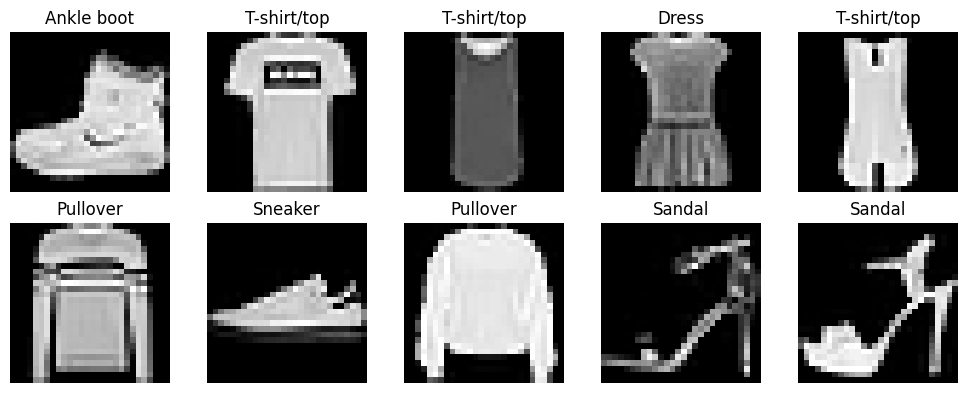

In [7]:

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Display ten sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()



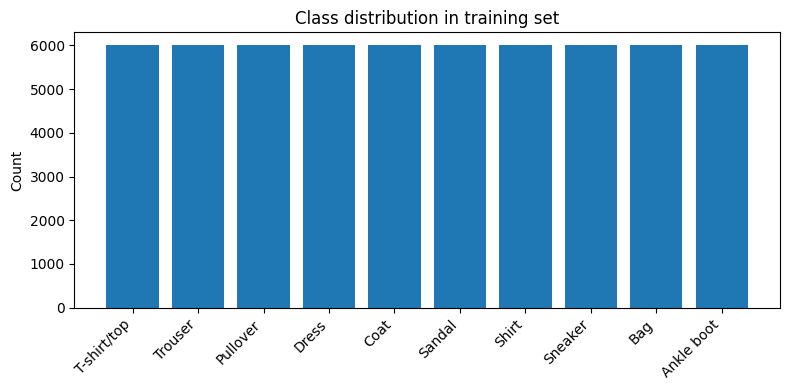

In [8]:

unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([class_names[u] for u in unique], counts)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Class distribution in training set")
plt.tight_layout()
plt.show()

In [9]:

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Before flattening:", X_train.shape)
print("After flattening:", X_train_flat.shape)


X_train_flat = X_train_flat.astype('float32') / 255.0
X_test_flat = X_test_flat.astype('float32') / 255.0

print("Pixel range before:", X_train.min(), "-", X_train.max())
print("Pixel range after:", X_train_flat.min(), "-", X_train_flat.max())


y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=10)

print("Label before one-hot:", y_train[0])
print("Label after one-hot:", y_train_oh[0])

Before flattening: (60000, 28, 28)
After flattening: (60000, 784)
Pixel range before: 0 - 255
Pixel range after: 0.0 - 1.0
Label before one-hot: 9
Label after one-hot: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_flat, y_train_oh,
    epochs=40,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8174 - loss: 0.5117 - val_accuracy: 0.8443 - val_loss: 0.4147
Epoch 2/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8642 - loss: 0.3756 - val_accuracy: 0.8688 - val_loss: 0.3724
Epoch 3/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8770 - loss: 0.3377 - val_accuracy: 0.8763 - val_loss: 0.3565
Epoch 4/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8836 - loss: 0.3143 - val_accuracy: 0.8710 - val_loss: 0.3581
Epoch 5/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8901 - loss: 0.2955 - val_accuracy: 0.8838 - val_loss: 0.3391
Epoch 6/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8946 - loss: 0.2819 - val_accuracy: 0.8810 - val_loss: 0.3265
Epoch 7/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8997 - loss: 0.2694 - val_accuracy: 0.8795 - val_loss: 0.3317
Epoch 8/40
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9028 - loss: 0.2570 

In [12]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import numpy as np


y_pred_probs = model.predict(X_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_oh, axis=1)

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy:  {acc:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1-score:       {f1:.4f}")

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy:  0.8880
Precision:      0.8874
Recall:         0.8880
F1-score:       0.8872
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.84      0.84      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.80      0.83      0.81      1000
       Dress       0.87      0.92      0.89      1000
        Coat       0.79      0.83      0.81      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.73      0.64      0.68      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[839   4   8  29   4   1 106   0   9   0]
 [  6 971   1  12   4   0   6   0   0   0]
 [ 16   0 829  20  86 

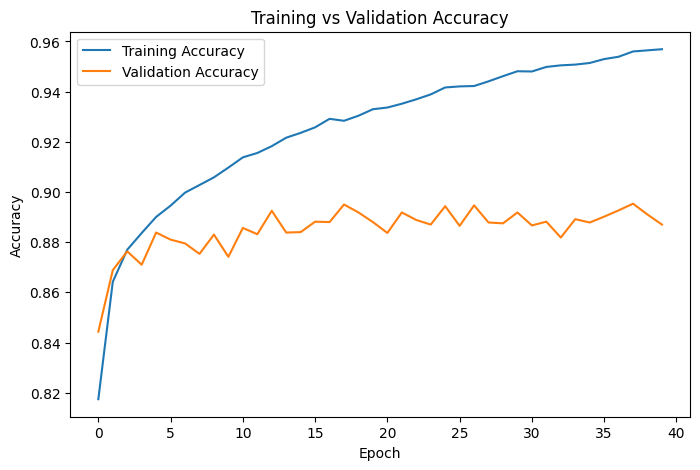

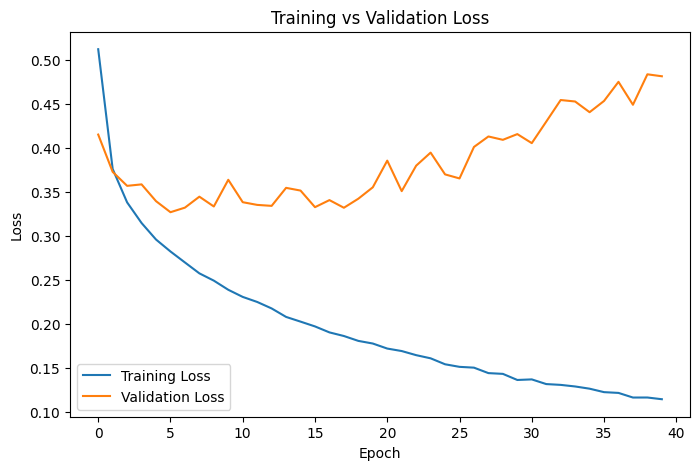

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(); plt.show()

# Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(); plt.show()

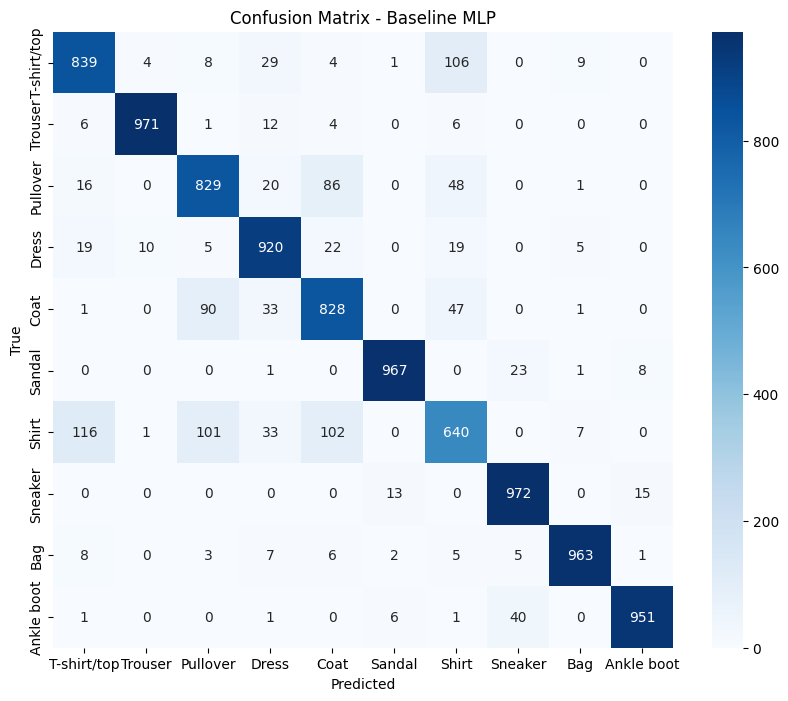

In [14]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - Baseline MLP')
plt.show()

In [15]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

def build_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                 activation='relu', dropout_rate=0.0, optimizer='adam'):
    model = Sequential()
    model.add(Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))

    opt_map = {
        'adam': tf.keras.optimizers.Adam(learning_rate=learning_rate),
        'sgd': tf.keras.optimizers.SGD(learning_rate=learning_rate),
        'rmsprop': tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    }
    model.compile(optimizer=opt_map[optimizer],
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

keras_clf = KerasClassifier(model=build_model, verbose=0)

param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'model__optimizer': ['sgd', 'adam', 'rmsprop'],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}

random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=1
)

random_search.fit(X_train_flat, y_train_oh)

print("Best hyperparameters:", random_search.best_params_)
print("Best CV accuracy:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END batch_size=32, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=2, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer=adam; total time= 1.3min
[CV] END batch_size=32, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=2, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer=adam; total time= 1.3min
[CV] END batch_size=32, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=2, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer=adam; total time= 1.3min
[CV] END batch_size=32, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=2, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer=adam; total time= 1.3min
[CV] END batch_size=32, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=2, model__hidden_

In [18]:
import sklearn, scikeras
print("sklearn:", sklearn.__version__)
print("scikeras:", scikeras.__version__)

sklearn: 1.5.0
scikeras: 0.13.0


In [19]:
import time

# --- Step 1: Pull out the best hyperparameters found by the search ---
best_params = random_search.best_params_
print("Best hyperparameters found:", best_params)
print("Best cross-validation accuracy:", random_search.best_score_)

# --- Step 2: Retrain a fresh model using those exact hyperparameters ---
# Strip the 'model__' prefix so we can pass these straight into build_model()
model_params = {k.replace('model__', ''): v for k, v in best_params.items()
                 if k.startswith('model__')}

optimized_model = build_model(**model_params)

start_time = time.time()
optimized_history = optimized_model.fit(
    X_train_flat, y_train_oh,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.1,
    verbose=1
)
optimized_training_time = time.time() - start_time

print(f"Optimized model training time: {optimized_training_time:.2f} seconds")

# --- Step 3: Evaluate the optimized model on the test set ---
y_pred_probs_opt = optimized_model.predict(X_test_flat)
y_pred_opt = np.argmax(y_pred_probs_opt, axis=1)
y_true = np.argmax(y_test_oh, axis=1)   # same as before, reused here

acc_opt = accuracy_score(y_true, y_pred_opt)
precision_opt = precision_score(y_true, y_pred_opt, average='macro')
recall_opt = recall_score(y_true, y_pred_opt, average='macro')
f1_opt = f1_score(y_true, y_pred_opt, average='macro')

print(f"Optimized Test Accuracy:  {acc_opt:.4f}")
print(f"Optimized Precision:      {precision_opt:.4f}")
print(f"Optimized Recall:         {recall_opt:.4f}")
print(f"Optimized F1-score:       {f1_opt:.4f}")

cm_opt = confusion_matrix(y_true, y_pred_opt)
print(cm_opt)

Best hyperparameters found: {'model__optimizer': 'adam', 'model__learning_rate': 0.001, 'model__hidden_neurons': 128, 'model__hidden_layers': 1, 'model__dropout_rate': 0.0, 'model__activation': 'relu', 'epochs': 20, 'batch_size': 64}
Best cross-validation accuracy: 0.8903166666666668
Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8189 - loss: 0.5193 - val_accuracy: 0.8550 - val_loss: 0.4108
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8612 - loss: 0.3895 - val_accuracy: 0.8677 - val_loss: 0.3746
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8744 - loss: 0.3502 - val_accuracy: 0.8697 - val_loss: 0.3702
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8829 - loss: 0.3225 - val_accuracy: 0.8797 - val_loss: 0.3494
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8855 - loss: 0.3090 - val_accuracy: 0.8798 - val_loss: 0.3360
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8932 - lo

In [21]:
import pandas as pd

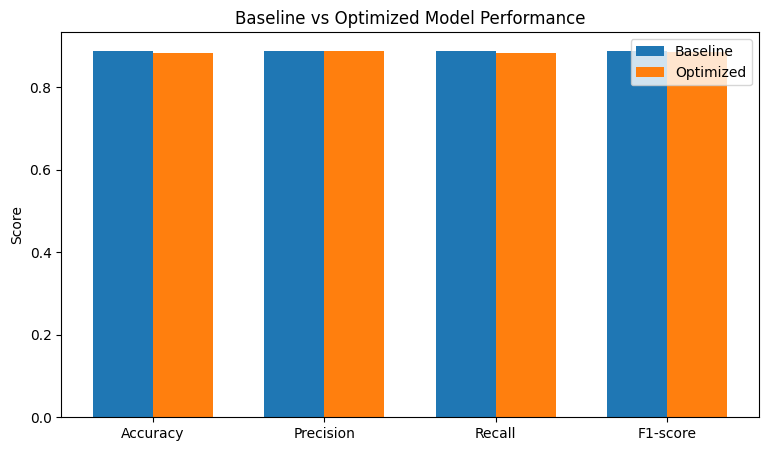

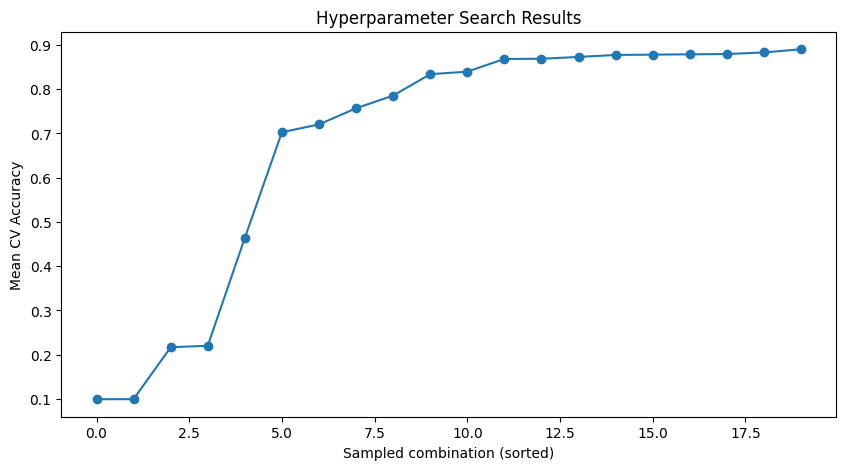

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Comparison bar chart: baseline vs optimized
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
baseline_scores = [acc, precision, recall, f1]        # from your Task 5 baseline eval
optimized_scores = [acc_opt, precision_opt, recall_opt, f1_opt]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, optimized_scores, width, label='Optimized')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Baseline vs Optimized Model Performance')
plt.legend()
plt.show()

# Hyperparameter search results plot: CV score per sampled combination
results_df = pd.DataFrame(random_search.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(results_df['mean_test_score'].sort_values().values, marker='o')
plt.xlabel('Sampled combination (sorted)')
plt.ylabel('Mean CV Accuracy')
plt.title('Hyperparameter Search Results')
plt.show()

Optimized Model - Classification Report
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.77      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.83      0.79      0.81      1000
       Dress       0.88      0.89      0.88      1000
        Coat       0.79      0.85      0.82      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.66      0.76      0.71      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.98      0.91      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



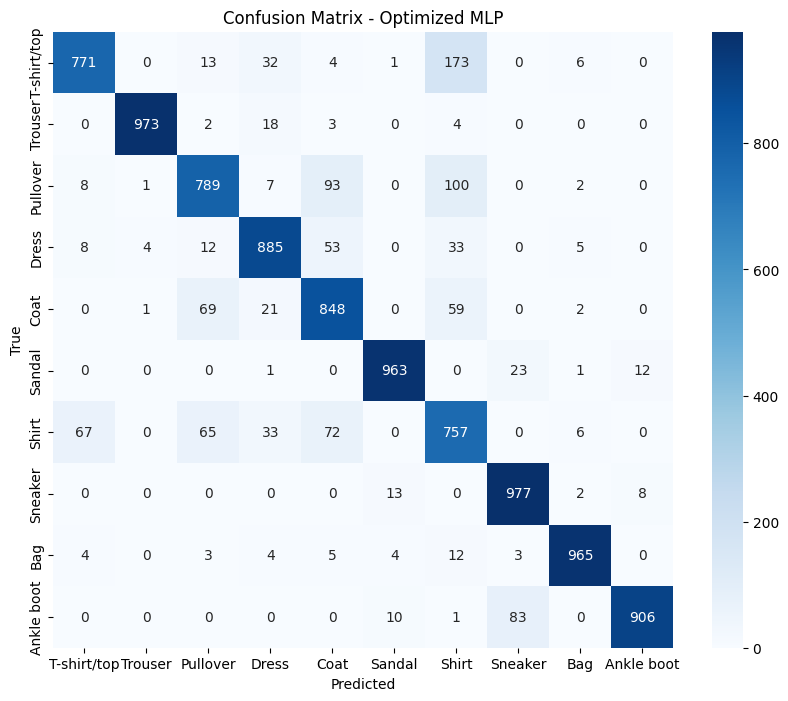

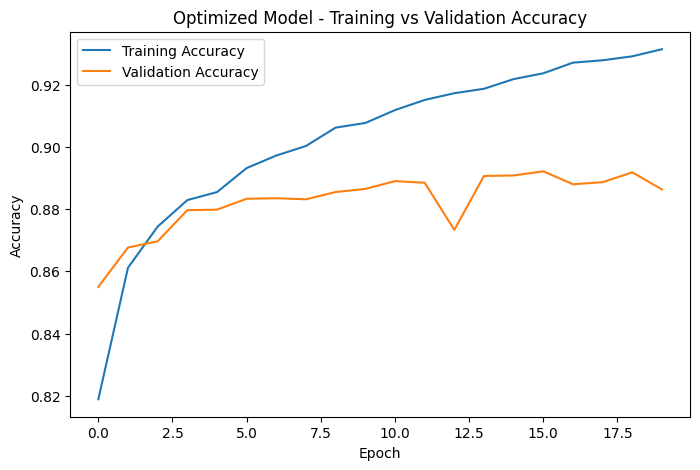

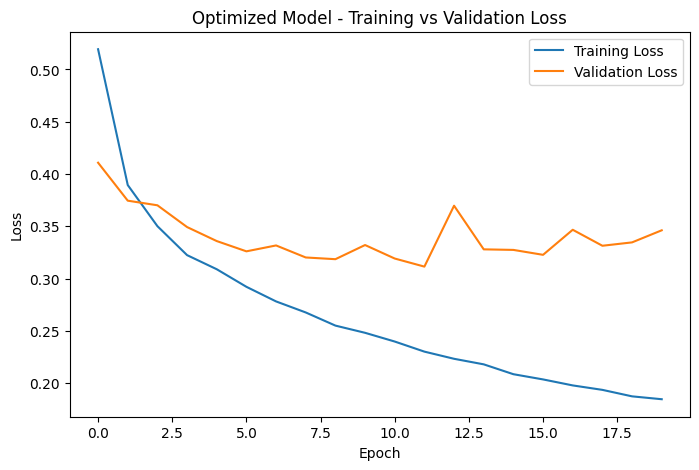

In [23]:
import seaborn as sns

# --- Classification report for the optimized model ---
print("Optimized Model - Classification Report")
print(classification_report(y_true, y_pred_opt, target_names=class_names))

# --- Confusion matrix heatmap for the optimized model ---
plt.figure(figsize=(10, 8))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - Optimized MLP')
plt.savefig('confusion_matrix_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Training curves for the optimized model (same idea as baseline) ---
plt.figure(figsize=(8, 5))
plt.plot(optimized_history.history['accuracy'], label='Training Accuracy')
plt.plot(optimized_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Optimized Model - Training vs Validation Accuracy')
plt.legend()
plt.savefig('optimized_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(optimized_history.history['loss'], label='Training Loss')
plt.plot(optimized_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Optimized Model - Training vs Validation Loss')
plt.legend()
plt.savefig('optimized_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# example — add this line right before each plt.show() you already have
plt.savefig('descriptive_filename.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>